# Submission Akhir DLTM



## 1. Import & Setup


In [ ]:
import os
import warnings
import time
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Random seed: {SEED}")

TensorFlow version: 2.21.0
NumPy version: 2.4.4
Pandas version: 3.0.2
Random seed: 42


## 2. Load Dataset

In [ ]:
local_path = 'Bitcoin3.csv'
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"Loaded from local file: {local_path}")
else:
    csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
    df = pd.read_csv(csv_url)
    print("Loaded from URL")

df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive statistics:")
print(df.describe())

Loaded from local file: Bitcoin3.csv

Dataset shape: (53150, 7)
Date range: 2017-09-21 09:00:00 to 2023-10-19 23:00:00

First 5 rows:
                 Date    Close   Volume USDT        RSI  MACD_Hist        ATR     KAMAO
0 2017-09-21 09:00:00  3860.00  74434.891166  49.192454 -48.279697  88.054720  2.495591
1 2017-09-21 10:00:00  3871.48  44687.318944  49.233202 -47.780476  87.996283  2.616710
2 2017-09-21 11:00:00  3864.95  80546.171672  49.210685 -47.308061  87.897128  2.532239
3 2017-09-21 12:00:00  3858.08  90331.531390  49.186948 -46.863233  87.720856  2.447245
4 2017-09-21 13:00:00  3839.96  39362.568750  49.123789 -46.482717  87.477117  2.323144

Missing values:
Date           0
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64

Descriptive statistics:
              Close   Volume USDT          RSI    MACD_Hist          ATR        KAMAO
count  53150.000000  5.315000e+04  53150.00000  53150.000000  53150.00000  531

## 3. Exploratory Data Analysis

### 3.1 Visualisasi Time Series Setiap Fitur

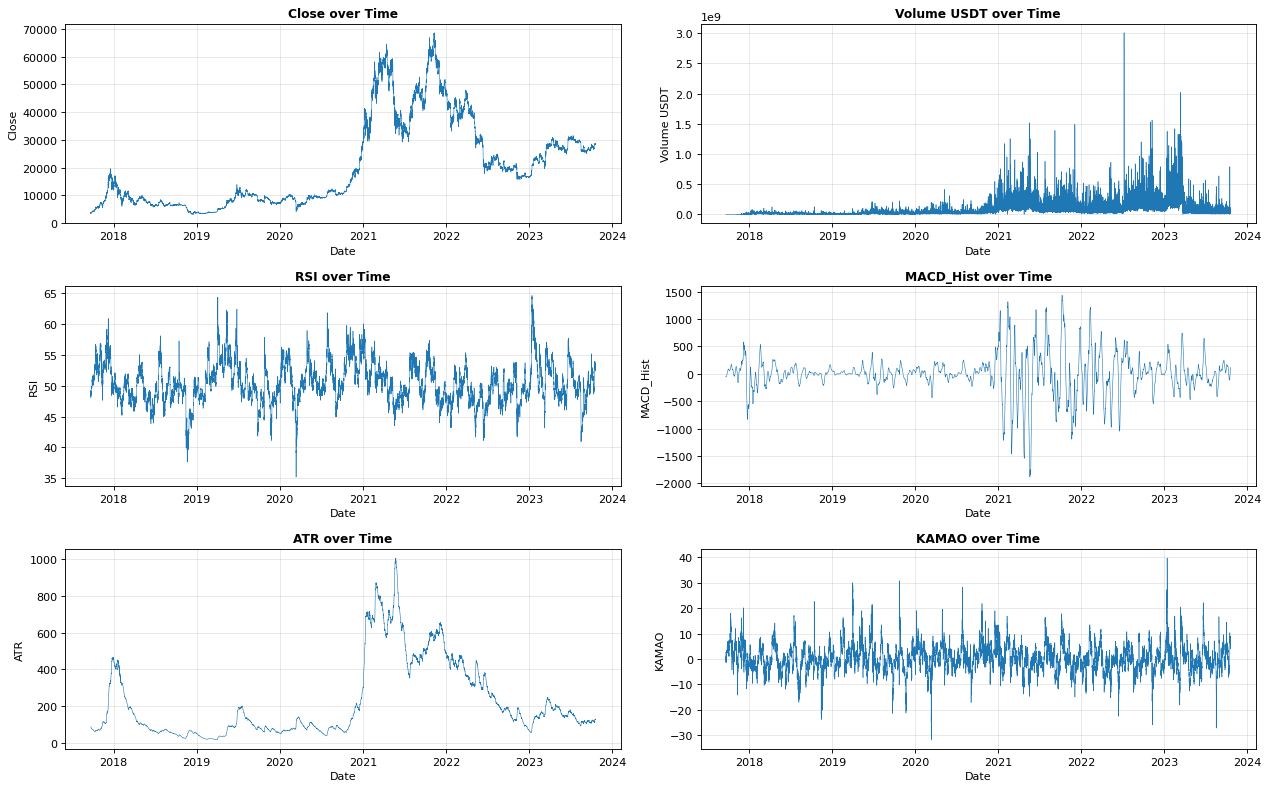

In [ ]:
# Plot time series untuk semua fitur
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
features_to_plot = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
for i, feat in enumerate(features_to_plot):
    ax = axes[i // 2, i % 2]
    ax.plot(df['Date'], df[feat], linewidth=0.5)
    ax.set_title(f'{feat} over Time', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel(feat)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Heatmap Korelasi Antar Fitur


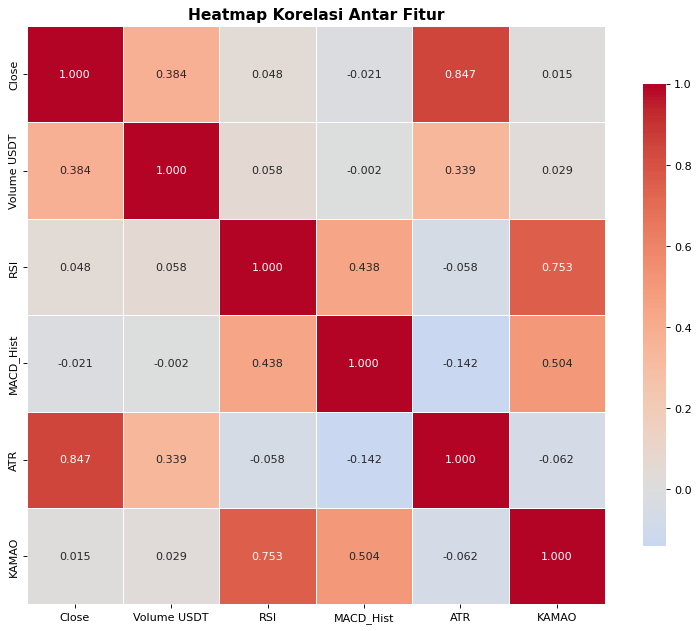


Korelasi dengan Close:
Close          1.000000
ATR            0.847282
Volume USDT    0.383990
RSI            0.047695
KAMAO          0.015203
MACD_Hist     -0.020707
Name: Close, dtype: float64


In [ ]:
# Heatmap korelasi
numeric_cols = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nKorelasi dengan Close:")
print(corr_matrix['Close'].sort_values(ascending=False))

### Analisis Heatmap:
- **ATR** (Average True Range) sangat berkorelasi positif dengan Close (0.85) → mengukur volatility yang tracking dengan harga
- **Volume USDT** punya korelasi moderate (0.38) → wajar karena harga tinggi sering disertai volume tinggi
- **RSI, MACD_Hist, KAMAO** korelasi rendah → ini adalah technical indicator yang justru bagus karena memberikan signal independent dari price level

Akan dipilih 5 fitur multivariate utama untuk forecasting + 2 rolling features (total 7 fitur).

## 4. Pemilihan Fitur Multivariate (≥3 fitur)

In [ ]:
SELECTED_FEATURES = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR']
TARGET_COL = 'Close'
TARGET_IDX = SELECTED_FEATURES.index(TARGET_COL)

print(f"Fitur yang dipilih ({len(SELECTED_FEATURES)} fitur): {SELECTED_FEATURES}")
print(f"Target column: {TARGET_COL} (index ke-{TARGET_IDX})")

Fitur yang dipilih (5 fitur): ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR']
Target column: Close (index ke-0)


## 5. Feature Engineering: Rolling Statistics
Kriteria Advanced Kriteria 1: membuat fitur baru menggunakan Rolling Statistic.
- **Rolling Mean (24 jam)**: menangkap tren harian
- **Rolling Std (24 jam)**: menangkap volatilitas harian

In [ ]:
df_feat = df[['Date'] + SELECTED_FEATURES].copy()
df_feat['Close_RollingMean_24'] = df_feat['Close'].rolling(window=24, min_periods=1).mean()
df_feat['Close_RollingStd_24'] = df_feat['Close'].rolling(window=24, min_periods=1).std().fillna(0)

df_feat = df_feat.dropna().reset_index(drop=True)
FEATURES_WITH_ENG = SELECTED_FEATURES + ['Close_RollingMean_24', 'Close_RollingStd_24']

print(f"Fitur final ({len(FEATURES_WITH_ENG)} fitur): {FEATURES_WITH_ENG}")
print(f"Shape after feature engineering: {df_feat.shape}")
print(f"\nSample 5 rows dengan rolling features:")
print(df_feat[['Date', 'Close', 'Close_RollingMean_24', 'Close_RollingStd_24']].head(30).tail(5))

Fitur final (7 fitur): ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'Close_RollingMean_24', 'Close_RollingStd_24']
Shape after feature engineering: (53150, 8)

Sample 5 rows dengan rolling features:
                 Date    Close  Close_RollingMean_24  Close_RollingStd_24
25 2017-09-22 10:00:00  3572.85           3686.520000            83.030244
26 2017-09-22 11:00:00  3539.97           3672.979167            79.071138
27 2017-09-22 12:00:00  3592.12           3661.897500            70.133487
28 2017-09-22 13:00:00  3566.11           3649.790833            59.289798
29 2017-09-22 14:00:00  3596.49           3642.038333            53.007381


## 6. Analisis Dekomposisi Data Target

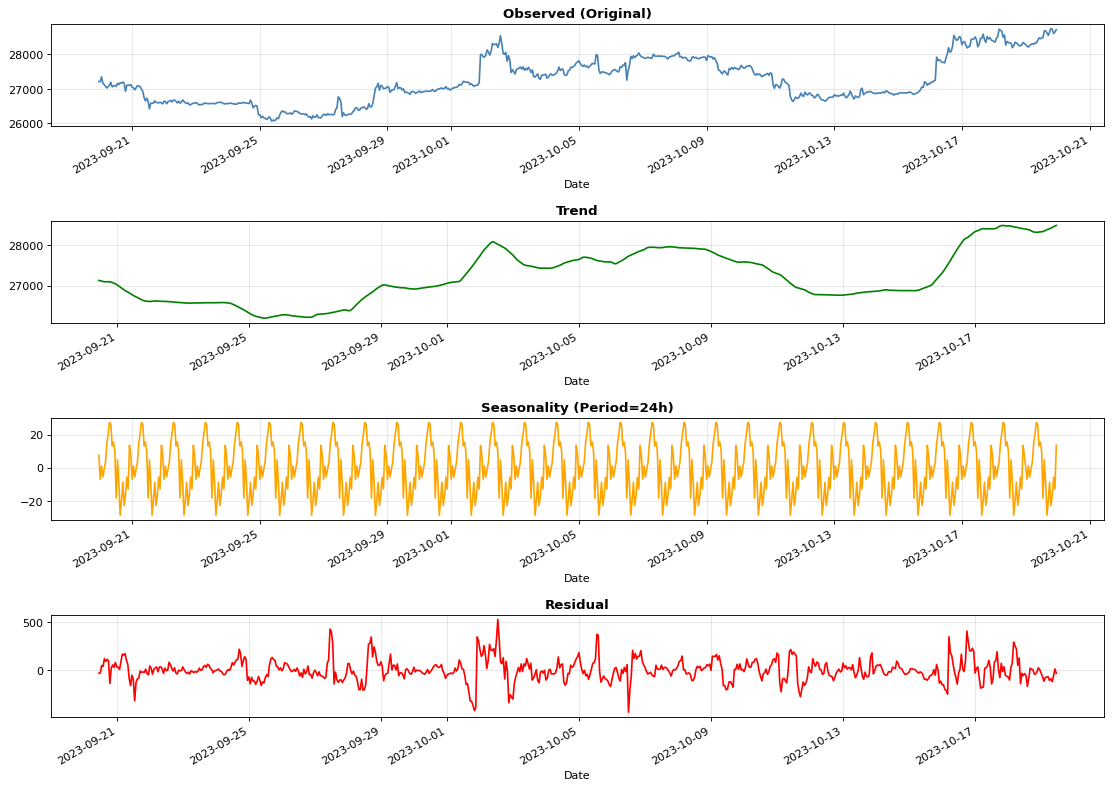

In [ ]:
sample_for_decomp = df_feat.set_index('Date')['Close'][-24*30:]
decomposition = seasonal_decompose(sample_for_decomp, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed (Original)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_title('Trend', fontweight='bold')
axes[1].grid(True, alpha=0.3)
decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_title('Seasonality (Period=24h)', fontweight='bold')
axes[2].grid(True, alpha=0.3)
decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual', fontweight='bold')
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analisis Dekomposisi:
- **Trend**: harga BTC menunjukkan tren menurun pada 30 hari terakhir
- **Seasonality**: ada pola harian (24-jam) yang berulang  
- **Residual**: noise/random fluctuation yang tidak terjelaskan trend & seasonality

## 7. Analisis ACF & PACF untuk Window Size

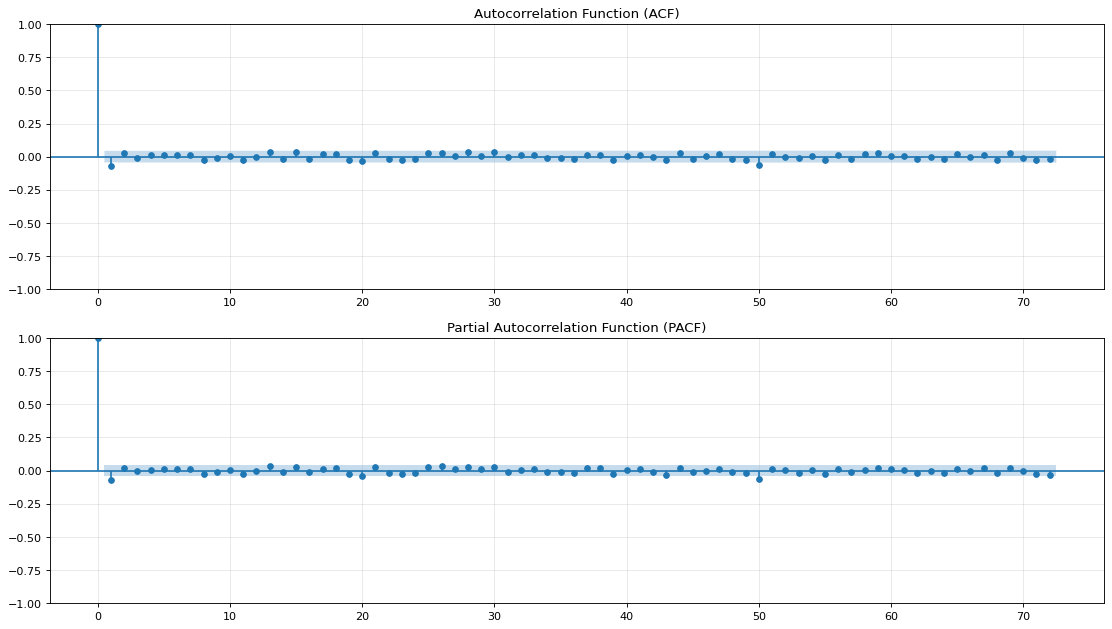

In [ ]:
close_diff = np.log(df_feat['Close']).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(close_diff[-2000:], lags=72, ax=axes[0], title='Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)
plot_pacf(close_diff[-2000:], lags=72, ax=axes[1], title='Partial Autocorrelation Function (PACF)', method='ywm')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analisis ACF & PACF:
- ACF menunjukkan signal autokorelasi pada lag harian (24 jam) dan periode pendek
- PACF menunjukkan dependensi yang signifikan pada lag-lag awal

**Keputusan window size = 48 (2 hari)** untuk:
- Menangkap pola harian (24 jam) + pola sub-harian
- Memberikan konteks cukup untuk multi-horizon prediction 24 langkah ke depan
- Tidak terlalu panjang sehingga komputasi efisien

## 8. Train/Val/Test Split (Chronological)


In [ ]:
data_array = df_feat[FEATURES_WITH_ENG].values.astype(np.float32)
print(f"Total data shape: {data_array.shape}")

n_total = len(data_array)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

train_data = data_array[:n_train]
val_data = data_array[n_train:n_train + n_val]
test_data = data_array[n_train + n_val:]

print(f"Train: {train_data.shape} ({df_feat['Date'].iloc[0]} -> {df_feat['Date'].iloc[n_train-1]})")
print(f"Val:   {val_data.shape} ({df_feat['Date'].iloc[n_train]} -> {df_feat['Date'].iloc[n_train+n_val-1]})")
print(f"Test:  {test_data.shape} ({df_feat['Date'].iloc[n_train+n_val]} -> {df_feat['Date'].iloc[-1]})")

Total data shape: (53150, 7)
Train: (37205, 7) (2017-09-21 09:00:00 -> 2021-12-24 12:00:00)
Val:   (7972, 7) (2021-12-24 13:00:00 -> 2022-11-21 16:00:00)
Test:  (7973, 7) (2022-11-21 17:00:00 -> 2023-10-19 23:00:00)


## 9. Normalisasi MinMaxScaler — TANPA Data Leakage

In [ ]:
# Buat scaler per kolom
feature_scalers = {}
for i, feat in enumerate(FEATURES_WITH_ENG):
    scaler = MinMaxScaler()
    scaler.fit(train_data[:, i:i+1])
    feature_scalers[feat] = scaler

def scale_data(arr, scalers, features):
    out = np.zeros_like(arr)
    for i, feat in enumerate(features):
        out[:, i] = scalers[feat].transform(arr[:, i:i+1]).flatten()
    return out

train_scaled = scale_data(train_data, feature_scalers, FEATURES_WITH_ENG)
val_scaled = scale_data(val_data, feature_scalers, FEATURES_WITH_ENG)
test_scaled = scale_data(test_data, feature_scalers, FEATURES_WITH_ENG)

target_scaler = feature_scalers[TARGET_COL]

print(f"Train scaled - min: {train_scaled.min():.4f}, max: {train_scaled.max():.4f}")
print(f"Val scaled   - min: {val_scaled.min():.4f}, max: {val_scaled.max():.4f}")
print(f"Test scaled  - min: {test_scaled.min():.4f}, max: {test_scaled.max():.4f}")
print("[OK] No data leakage: scaler hanya di-fit pada train data!")

Train scaled - min: 0.0000, max: 1.0000
Val scaled   - min: 0.0048, max: 1.9846
Test scaled  - min: 0.0000, max: 1.3332
[OK] No data leakage: scaler hanya di-fit pada train data!


## 10. Windowing — Multi-step Multi-variate
- **Window size (input)**: 48 jam (2 hari historis)
- **Horizon (output)**: 24 jam ke depan
- **Target**: hanya kolom Close

In [ ]:
WINDOW_SIZE = 48
HORIZON = 24
N_FEATURES = len(FEATURES_WITH_ENG)
BATCH_SIZE = 128

def create_windows(data, window_size, horizon, target_idx):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_windows(train_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)
X_val, y_val = create_windows(val_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)
X_test, y_test = create_windows(test_scaled, WINDOW_SIZE, HORIZON, TARGET_IDX)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (37134, 48, 7), y_train: (37134, 24)
X_val:   (7901, 48, 7), y_val:   (7901, 24)
X_test:  (7902, 48, 7), y_test:  (7902, 24)


## 11. tf.data.Dataset Pipeline


In [ ]:
def build_dataset(X, y, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(X)), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

SUBSET_TRAIN = 3000
SUBSET_VAL = 800
X_train_sub = X_train[-SUBSET_TRAIN:]
y_train_sub = y_train[-SUBSET_TRAIN:]
X_val_sub = X_val[-SUBSET_VAL:]
y_val_sub = y_val[-SUBSET_VAL:]

train_ds = build_dataset(X_train_sub, y_train_sub, BATCH_SIZE, shuffle=True)
val_ds = build_dataset(X_val_sub, y_val_sub, BATCH_SIZE)
test_ds = build_dataset(X_test, y_test, BATCH_SIZE)

print(f"Train dataset: {train_ds}")
print(f"Val dataset:   {val_ds}")
print(f"Test dataset:  {test_ds}")

# Sample batch inspection
for x_batch, y_batch in train_ds.take(1):
    print(f"\nSample batch X: {x_batch.shape}, y: {y_batch.shape}")

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 48, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None, 24), dtype=tf.float32, name=None))>
Val dataset:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 48, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None, 24), dtype=tf.float32, name=None))>
Test dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 48, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None, 24), dtype=tf.float32, name=None))>

Sample batch X: (128, 48, 7), y: (128, 24)


# Custom Components (Dibangun Dari Nol)

## 12. Custom Dense Layer


In [ ]:
class CustomDense(layers.Layer):
    def __init__(self, units, activation=None, use_bias=True,
                 kernel_initializer='glorot_uniform', name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias
        self.kernel_initializer = tf.keras.initializers.get(kernel_initializer)

    def build(self, input_shape):
        # Bobot W: (input_dim, units)
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer=self.kernel_initializer,
            trainable=True,
        )
        if self.use_bias:
            self.b = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w)
        if self.use_bias:
            output = output + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
        })
        return config

# Test
test_layer = CustomDense(units=16, activation='relu')
test_x = tf.random.normal((4, 8))
test_out = test_layer(test_x)
print(f"CustomDense test: input {test_x.shape} -> output {test_out.shape}")

CustomDense test: input (4, 8) -> output (4, 16)


## 13. Custom Multi-Head Attention Layer


In [ ]:
class CustomMultiHeadAttention(layers.Layer):
    def __init__(self, num_heads, key_dim, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.total_dim = num_heads * key_dim

    def build(self, input_shape):
        last_dim = input_shape[-1]
        self.wq = self.add_weight(name='wq', shape=(last_dim, self.total_dim),
                                   initializer='glorot_uniform', trainable=True)
        self.wk = self.add_weight(name='wk', shape=(last_dim, self.total_dim),
                                   initializer='glorot_uniform', trainable=True)
        self.wv = self.add_weight(name='wv', shape=(last_dim, self.total_dim),
                                   initializer='glorot_uniform', trainable=True)
        self.wo = self.add_weight(name='wo', shape=(self.total_dim, last_dim),
                                   initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, query, value=None, key=None):
        if value is None: value = query
        if key is None: key = value
        batch_size = tf.shape(query)[0]
        q = tf.matmul(query, self.wq)
        k = tf.matmul(key, self.wk)
        v = tf.matmul(value, self.wv)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        # Scaled dot-product attention
        scores = tf.matmul(q, k, transpose_b=True)
        scale = tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        scores = scores / scale
        weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(weights, v)
        # Concat heads
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        output = tf.reshape(output, (batch_size, -1, self.total_dim))
        # Final linear projection
        output = tf.matmul(output, self.wo)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return config

# Test
test_mha = CustomMultiHeadAttention(num_heads=4, key_dim=8)
test_x = tf.random.normal((4, 10, 32))
test_out = test_mha(test_x)
print(f"CustomMHA test: input {test_x.shape} -> output {test_out.shape}")

CustomMHA test: input (4, 10, 32) -> output (4, 10, 32)


## 14. Custom Dropout & Custom Leaky ReLU


In [ ]:
class CustomDropout(layers.Layer):
    def __init__(self, rate, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training and self.rate > 0:
            keep_prob = 1.0 - self.rate
            mask = tf.random.uniform(tf.shape(inputs)) < keep_prob
            mask = tf.cast(mask, inputs.dtype)
            return inputs * mask / keep_prob  # Inverse scaling
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config


class CustomLeakyReLU(layers.Layer):
    def __init__(self, alpha=0.1, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha = alpha

    def call(self, inputs):
        return tf.where(inputs > 0, inputs, self.alpha * inputs)

    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha})
        return config

# Test
print("CustomDropout test:")
test_drop = CustomDropout(rate=0.3)
print(f"  Input (4,8) -> Output: {test_drop(tf.ones((4,8)), training=True).shape}")

print("CustomLeakyReLU test:")
test_lrelu = CustomLeakyReLU(alpha=0.1)
test_in = tf.constant([[-1.0, 0.5, -2.0, 3.0]])
print(f"  {test_in.numpy()} -> {test_lrelu(test_in).numpy()}")

CustomDropout test:
  Input (4,8) -> Output: (4, 8)
CustomLeakyReLU test:
  [[-1.   0.5 -2.   3. ]] -> [[-0.1  0.5 -0.2  3. ]]


## 15. Custom Loss Functions


In [ ]:
class CustomMAELoss(tf.keras.losses.Loss):
    def __init__(self, name='custom_mae'):
        super().__init__(name=name)

    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.abs(y_true - y_pred))


class WeightedHorizonMAELoss(tf.keras.losses.Loss):
    def __init__(self, horizon=24, weight_increment=0.02, name='weighted_horizon_mae'):
        super().__init__(name=name)
        self.horizon = horizon
        self.weight_increment = weight_increment
        self.step_weights = tf.constant(
            [1.0 + i * weight_increment for i in range(horizon)],
            dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        abs_err = tf.abs(y_true - y_pred)
        weighted_err = abs_err * self.step_weights  # broadcasting
        return tf.reduce_mean(weighted_err)

# Test
y_t = tf.constant([[1.0, 2.0, 3.0]])
y_p = tf.constant([[1.5, 1.8, 3.2]])
print(f"CustomMAELoss({y_t.numpy()}, {y_p.numpy()}) = {CustomMAELoss()(y_t, y_p):.4f}")
print(f"WeightedHorizonMAELoss(horizon=3, inc=0.2) = {WeightedHorizonMAELoss(3, 0.2)(y_t, y_p):.4f}")

CustomMAELoss([[1. 2. 3.]], [[1.5 1.8 3.2]]) = 0.3000
WeightedHorizonMAELoss(horizon=3, inc=0.2) = 0.3400


## 16. Custom Callbacks


In [ ]:
class CustomEarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = np.inf
        self.wait = 0
        self.best_weights = None
        self.stopped_epoch = None
        self.should_stop = False

    def reset(self):
        self.best_loss = np.inf
        self.wait = 0
        self.best_weights = None
        self.stopped_epoch = None
        self.should_stop = False

    def on_epoch_end(self, epoch, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = [w.numpy() for w in model.weights]
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.should_stop = True
                self.stopped_epoch = epoch
                if self.restore_best_weights and self.best_weights is not None:
                    for i, w in enumerate(model.weights):
                        w.assign(self.best_weights[i])
                    print(f"  -> Restored best weights from epoch with val_loss={self.best_loss:.6f}")
        return self.should_stop


class CustomReduceLROnPlateau:
    def __init__(self, factor=0.5, patience=5, min_lr=1e-7, min_delta=1e-5):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.wait = 0

    def reset(self):
        self.best_loss = np.inf
        self.wait = 0

    def on_epoch_end(self, epoch, val_loss, optimizer):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(optimizer.learning_rate.numpy())
                new_lr = max(old_lr * self.factor, self.min_lr)
                if new_lr < old_lr:
                    optimizer.learning_rate.assign(new_lr)
                    print(f"  -> ReduceLR: {old_lr:.2e} -> {new_lr:.2e}")
                self.wait = 0

print("[OK] Custom callbacks defined")

[OK] Custom callbacks defined


# Model Architectures

## 17. Model 1 — LSTM Baseline (Functional API)


In [ ]:
def build_baseline_lstm(window_size=48, n_features=7, horizon=24,
                        lstm_units=64, num_heads=2, key_dim=16):
    inputs = Input(shape=(window_size, n_features), name='input')
    x = layers.LSTM(lstm_units, return_sequences=True, name='lstm_1')(inputs)

    # Custom Multi-Head Attention (self-attention)
    attn_out = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                         name='custom_mha')(x)
    # Residual connection + LayerNorm
    x = layers.LayerNormalization(name='ln_1')(x + attn_out)
    x = CustomDropout(rate=0.2, name='custom_dropout')(x)

    x = layers.LSTM(lstm_units, name='lstm_2')(x)
    x = CustomLeakyReLU(alpha=0.1, name='custom_lrelu')(x)
    x = CustomDense(64, activation='relu', name='custom_dense_1')(x)
    outputs = CustomDense(horizon, activation=None, name='custom_dense_out')(x)

    model = Model(inputs=inputs, outputs=outputs, name='LSTM_Baseline')
    return model

# Build & summary
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)
model_baseline = build_baseline_lstm(WINDOW_SIZE, N_FEATURES, HORIZON,
                                      lstm_units=48, num_heads=2, key_dim=16)
model_baseline.summary(line_length=100)

Model: "LSTM_Baseline"
_________________________________________________________________
 Layer (type)                Output Shape         Param #   Connected to
 input (InputLayer)          (None, 48, 7)        0         []
 lstm_1 (LSTM)               (None, 48, 48)       10,752    input
 custom_mha                  (None, None, 48)     6,144     lstm_1
 (CustomMultiHeadAttention)
 add (Add)                   (None, 48, 48)       0         lstm_1, custom_mha
 ln_1 (LayerNormalization)   (None, 48, 48)       96        add
 custom_dropout              (None, 48, 48)       0         ln_1
 (CustomDropout)
 lstm_2 (LSTM)               (None, 48)           18,624    custom_dropout
 custom_lrelu                (None, 48)           0         lstm_2
 (CustomLeakyReLU)
 custom_dense_1              (None, 64)           3,136     custom_lrelu
 (CustomDense)
 custom_dense_out            (None, 24)           1,560     custom_dense_1
 (CustomDense)
Total params: 40,312 (157.47 KB)
Trainable params:

## 18. Model 2 — Seq2Seq LSTM dengan Teacher Forcing (Functional API)
Architecture: Encoder-Decoder dengan teacher forcing untuk training.
- **Saat training**: decoder pakai teacher forcing input (ground truth shifted)
- **Saat inference**: pakai autoregressive (feed prediksi sebelumnya)

In [ ]:
def build_seq2seq_functional(window_size=48, n_features=7, horizon=24,
                              lstm_units=64, num_heads=2, key_dim=16):
    # ENCODER
    encoder_inputs = Input(shape=(window_size, n_features), name='encoder_input')
    encoder_outputs = layers.LSTM(lstm_units, return_sequences=True, name='enc_lstm_1')(encoder_inputs)

    # MHA pada encoder output
    encoder_attn = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                             name='enc_mha')(encoder_outputs)
    encoder_outputs = layers.LayerNormalization(name='enc_ln')(encoder_outputs + encoder_attn)
    encoder_outputs = CustomDropout(rate=0.2, name='enc_dropout')(encoder_outputs)

    _, state_h, state_c = layers.LSTM(lstm_units, return_state=True, name='enc_lstm_2')(encoder_outputs)
    encoder_states = [state_h, state_c]

    # DECODER
    decoder_inputs = Input(shape=(horizon, 1), name='decoder_input')
    decoder_outputs, _, _ = layers.LSTM(lstm_units, return_sequences=True, return_state=True,
                                         name='dec_lstm')(decoder_inputs, initial_state=encoder_states)
    decoder_outputs = CustomLeakyReLU(alpha=0.1, name='dec_lrelu')(decoder_outputs)
    decoder_outputs = CustomDense(64, activation='relu', name='dec_dense_1')(decoder_outputs)
    outputs = CustomDense(1, activation=None, name='dec_dense_out')(decoder_outputs)
    outputs = layers.Reshape((horizon,), name='reshape_out')(outputs)

    model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs,
                  name='Seq2Seq_LSTM_Functional_TF')
    return model

# Build & summary
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)
model_s2s_func = build_seq2seq_functional(WINDOW_SIZE, N_FEATURES, HORIZON,
                                            lstm_units=48, num_heads=2, key_dim=16)
print(f"Total params: {model_s2s_func.count_params():,}")

Total params: 48,417


## 19. Model 3 — Seq2Seq LSTM (Model Subclassing)
Kriteria Skilled Kriteria 2: Seq2Seq via Model Subclassing.

Subclassing memberi fleksibilitas untuk implementasi `predict_autoregressive` langsung dalam class.

In [ ]:
class Seq2SeqLSTMSubclass(Model):
    def __init__(self, lstm_units=128, horizon=24, num_heads=4, key_dim=32, **kwargs):
        super().__init__(**kwargs)
        self.lstm_units = lstm_units
        self.horizon = horizon
        self.num_heads = num_heads
        self.key_dim = key_dim

        # Encoder
        self.enc_lstm_1 = layers.LSTM(lstm_units, return_sequences=True, name='enc_lstm_1')
        self.enc_mha = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, name='enc_mha')
        self.enc_ln = layers.LayerNormalization(name='enc_ln')
        self.enc_dropout = CustomDropout(rate=0.2, name='enc_dropout')
        self.enc_lstm_2 = layers.LSTM(lstm_units, return_state=True, name='enc_lstm_2')

        # Decoder
        self.dec_lstm = layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='dec_lstm')
        self.dec_lrelu = CustomLeakyReLU(alpha=0.1, name='dec_lrelu')
        self.dec_dense_1 = CustomDense(64, activation='relu', name='dec_dense_1')
        self.dec_dense_out = CustomDense(1, activation=None, name='dec_dense_out')

    def get_config(self):
        config = super().get_config()
        config.update({
            'lstm_units': self.lstm_units, 'horizon': self.horizon,
            'num_heads': self.num_heads, 'key_dim': self.key_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def encode(self, encoder_inputs, training=False):
        x = self.enc_lstm_1(encoder_inputs, training=training)
        attn = self.enc_mha(x)
        x = self.enc_ln(x + attn)
        x = self.enc_dropout(x, training=training)
        _, h, c = self.enc_lstm_2(x, training=training)
        return [h, c]

    def decode_step(self, dec_input, state, training=False):
        dec_out, h, c = self.dec_lstm(dec_input, initial_state=state, training=training)
        dec_out = self.dec_lrelu(dec_out)
        dec_out = self.dec_dense_1(dec_out)
        out = self.dec_dense_out(dec_out)
        return out, [h, c]

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        state = self.encode(encoder_inputs, training=training)
        dec_out, _, _ = self.dec_lstm(decoder_inputs, initial_state=state, training=training)
        dec_out = self.dec_lrelu(dec_out)
        dec_out = self.dec_dense_1(dec_out)
        out = self.dec_dense_out(dec_out)
        return tf.squeeze(out, axis=-1)

    def predict_autoregressive(self, encoder_inputs, start_token=None):
        batch_size = tf.shape(encoder_inputs)[0]
        state = self.encode(encoder_inputs, training=False)

        if start_token is None:
            start_token = encoder_inputs[:, -1:, 0:1]

        current_input = start_token
        predictions = []
        for _ in range(self.horizon):
            out, state = self.decode_step(current_input, state, training=False)
            predictions.append(out)
            current_input = out

        result = tf.concat(predictions, axis=1)
        return tf.squeeze(result, axis=-1)


# Build & test
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)
model_s2s_sub = Seq2SeqLSTMSubclass(lstm_units=48, horizon=24, num_heads=2, key_dim=16)
_ = model_s2s_sub([tf.zeros((1, WINDOW_SIZE, N_FEATURES)), tf.zeros((1, HORIZON, 1))])
print(f"Total params: {sum(np.prod(v.shape) for v in model_s2s_sub.trainable_weights):,}")

Total params: 48417


# Custom Training Loop dengan tf.GradientTape

## 20. Generic Custom Training Function
Kriteria Basic Kriteria 3: tf.GradientTape custom training loop.

In [ ]:
def custom_train(model, train_ds, val_ds, loss_fn, optimizer, model_type='baseline',
                  epochs=20, es_patience=5, lr_patience=3):
    es = CustomEarlyStopping(patience=es_patience, restore_best_weights=True); es.reset()
    rlr = CustomReduceLROnPlateau(factor=0.5, patience=lr_patience, min_lr=1e-7); rlr.reset()
    history = {'loss': [], 'val_loss': [], 'lr': []}

    for ep in range(1, epochs+1):
        t0 = time.time()
        # Training step
        train_l = []
        for x, y in train_ds:
            with tf.GradientTape() as tape:
                if model_type == 'baseline':
                    p = model(x, training=True)
                else:
                    start_tok = x[:, -1:, 0:1]
                    y_shift = tf.expand_dims(y[:, :-1], axis=-1)
                    dec_input = tf.concat([start_tok, y_shift], axis=1)
                    p = model([x, dec_input], training=True)
                l = loss_fn(y, p)
            g = tape.gradient(l, model.trainable_variables)
            optimizer.apply_gradients(zip(g, model.trainable_variables))
            train_l.append(l.numpy())
        avg_t = float(np.mean(train_l))

        # Validation step
        val_l = []
        for x, y in val_ds:
            if model_type == 'baseline':
                p = model(x, training=False)
            else:
                start_tok = x[:, -1:, 0:1]
                y_shift = tf.expand_dims(y[:, :-1], axis=-1)
                dec_input = tf.concat([start_tok, y_shift], axis=1)
                p = model([x, dec_input], training=False)
            val_l.append(loss_fn(y, p).numpy())
        avg_v = float(np.mean(val_l))

        lr = float(optimizer.learning_rate.numpy())
        history['loss'].append(avg_t); history['val_loss'].append(avg_v); history['lr'].append(lr)
        elapsed = time.time() - t0
        print(f"Ep {ep:2d}/{epochs} | loss={avg_t:.6f} | val_loss={avg_v:.6f} | lr={lr:.2e} | {elapsed:.1f}s")

        # Apply callbacks
        rlr.on_epoch_end(ep, avg_v, optimizer)
        if es.on_epoch_end(ep, avg_v, model):
            print(f"[EarlyStopping] Stopped at epoch {ep}, best val_loss={es.best_loss:.6f}")
            break

    return history

print("[OK] Custom training function ready")

[OK] Custom training function ready


## 21. Train Model 1 — LSTM Baseline
Loss: **CustomMAELoss** (MAE biasa).

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

model_baseline = build_baseline_lstm(WINDOW_SIZE, N_FEATURES, HORIZON,
                                      lstm_units=48, num_heads=2, key_dim=16)
print(f"Params: {model_baseline.count_params():,}")

opt_baseline = tf.keras.optimizers.Adam(learning_rate=2e-3)
hist_baseline = custom_train(
    model_baseline, train_ds, val_ds,
    loss_fn=CustomMAELoss(),
    optimizer=opt_baseline,
    model_type='baseline',
    epochs=12, es_patience=4, lr_patience=2)

# Save model
model_baseline.save('model_baseline_LSTM.keras')
print("\n[OK] Saved: model_baseline_LSTM.keras")

Params: 40,312
Ep  1/12 | loss=0.374831 | val_loss=0.488978 | lr=2.00e-03 | 13.7s
Ep  2/12 | loss=0.106987 | val_loss=0.486087 | lr=2.00e-03 | 13.0s
Ep  3/12 | loss=0.093446 | val_loss=0.481556 | lr=2.00e-03 | 13.3s
Ep  4/12 | loss=0.062894 | val_loss=0.319866 | lr=2.00e-03 | 13.0s
Ep  5/12 | loss=0.033828 | val_loss=0.321219 | lr=2.00e-03 | 13.0s
Ep  6/12 | loss=0.028374 | val_loss=0.251176 | lr=2.00e-03 | 13.2s
Ep  7/12 | loss=0.028521 | val_loss=0.224358 | lr=2.00e-03 | 13.0s
Ep  8/12 | loss=0.025433 | val_loss=0.168344 | lr=2.00e-03 | 13.2s
Ep  9/12 | loss=0.024478 | val_loss=0.089571 | lr=2.00e-03 | 13.5s
Ep 10/12 | loss=0.023977 | val_loss=0.085578 | lr=2.00e-03 | 13.4s
Ep 11/12 | loss=0.023270 | val_loss=0.088620 | lr=2.00e-03 | 13.6s
Ep 12/12 | loss=0.021702 | val_loss=0.061732 | lr=2.00e-03 | 13.5s

[OK] Saved: model_baseline_LSTM.keras


## 22. Train Model 2 — Seq2Seq LSTM (Functional + Teacher Forcing)
Loss: **WeightedHorizonMAELoss** (Advanced criteria — bobot lebih besar untuk horizon jauh).

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

model_s2s_func = build_seq2seq_functional(WINDOW_SIZE, N_FEATURES, HORIZON,
                                            lstm_units=48, num_heads=2, key_dim=16)
print(f"Params: {model_s2s_func.count_params():,}")

opt_s2s_func = tf.keras.optimizers.Adam(learning_rate=2e-3)
hist_s2s_func = custom_train(
    model_s2s_func, train_ds, val_ds,
    loss_fn=WeightedHorizonMAELoss(horizon=HORIZON, weight_increment=0.02),
    optimizer=opt_s2s_func,
    model_type='seq2seq_tf',
    epochs=12, es_patience=4, lr_patience=2)

model_s2s_func.save('model_seq2seq_LSTM.keras')
print("\n[OK] Saved: model_seq2seq_LSTM.keras")

Params: 48,417
Ep  1/12 | loss=0.217870 | val_loss=0.246842 | lr=2.00e-03 | 16.5s
Ep  2/12 | loss=0.054911 | val_loss=0.112897 | lr=2.00e-03 | 15.7s
Ep  3/12 | loss=0.023880 | val_loss=0.093035 | lr=2.00e-03 | 16.1s
Ep  4/12 | loss=0.017764 | val_loss=0.085657 | lr=2.00e-03 | 15.7s
Ep  5/12 | loss=0.015340 | val_loss=0.077324 | lr=2.00e-03 | 16.0s
Ep  6/12 | loss=0.014633 | val_loss=0.075284 | lr=2.00e-03 | 16.6s
Ep  7/12 | loss=0.014034 | val_loss=0.064566 | lr=2.00e-03 | 16.2s
Ep  8/12 | loss=0.013114 | val_loss=0.053413 | lr=2.00e-03 | 16.8s
Ep  9/12 | loss=0.013117 | val_loss=0.056238 | lr=2.00e-03 | 16.6s
Ep 10/12 | loss=0.011747 | val_loss=0.057499 | lr=2.00e-03 | 17.2s
  -> ReduceLR: 2.00e-03 -> 1.00e-03
Ep 11/12 | loss=0.010666 | val_loss=0.051290 | lr=1.00e-03 | 16.1s
Ep 12/12 | loss=0.010328 | val_loss=0.046933 | lr=1.00e-03 | 16.6s

[OK] Saved: model_seq2seq_LSTM.keras


## 23. Train Model 3 — Seq2Seq LSTM (Subclassing)
Loss: **WeightedHorizonMAELoss**.

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

model_s2s_sub = Seq2SeqLSTMSubclass(lstm_units=48, horizon=HORIZON, num_heads=2, key_dim=16)
_ = model_s2s_sub([tf.zeros((1, WINDOW_SIZE, N_FEATURES)), tf.zeros((1, HORIZON, 1))])
print(f"Params: {sum(np.prod(v.shape) for v in model_s2s_sub.trainable_weights):,}")

opt_s2s_sub = tf.keras.optimizers.Adam(learning_rate=2e-3)
hist_s2s_sub = custom_train(
    model_s2s_sub, train_ds, val_ds,
    loss_fn=WeightedHorizonMAELoss(horizon=HORIZON, weight_increment=0.02),
    optimizer=opt_s2s_sub,
    model_type='seq2seq_tf',
    epochs=12, es_patience=4, lr_patience=2)

model_s2s_sub.save('best_model_seq2seq_LSTM.keras')
print("\n[OK] Saved: best_model_seq2seq_LSTM.keras")

Params: 48,417
Ep  1/12 | loss=0.208209 | val_loss=0.362690 | lr=2.00e-03 | 16.3s
Ep  2/12 | loss=0.061559 | val_loss=0.058471 | lr=2.00e-03 | 16.0s
Ep  3/12 | loss=0.039234 | val_loss=0.089250 | lr=2.00e-03 | 15.9s
Ep  4/12 | loss=0.024573 | val_loss=0.086799 | lr=2.00e-03 | 16.4s
  -> ReduceLR: 2.00e-03 -> 1.00e-03
Ep  5/12 | loss=0.015711 | val_loss=0.083315 | lr=1.00e-03 | 16.1s
Ep  6/12 | loss=0.013457 | val_loss=0.078785 | lr=1.00e-03 | 16.2s
  -> ReduceLR: 1.00e-03 -> 5.00e-04
  -> Restored best weights from epoch with val_loss=0.058471
[EarlyStopping] Stopped at epoch 6, best val_loss=0.058471

[OK] Saved: best_model_seq2seq_LSTM.keras


## 24. Training Curves untuk Semua Model

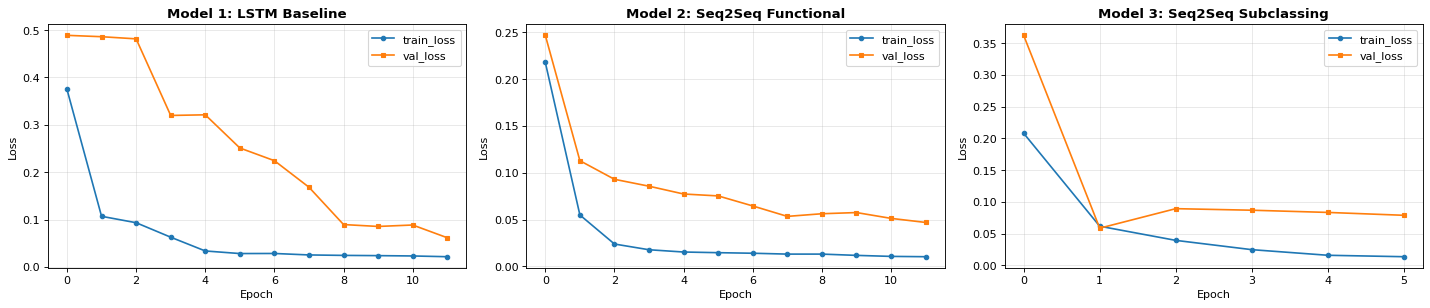

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, name in zip(axes,
    [hist_baseline, hist_s2s_func, hist_s2s_sub],
    ['Model 1: LSTM Baseline', 'Model 2: Seq2Seq Functional', 'Model 3: Seq2Seq Subclassing']):
    ax.plot(hist['loss'], label='train_loss', marker='o', markersize=4)
    ax.plot(hist['val_loss'], label='val_loss', marker='s', markersize=4)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(name, fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Inference & Evaluation

## 25. Autoregressive Inference untuk Seq2Seq
Kriteria Basic Kriteria 3: untuk Seq2Seq gunakan **Autoregressive** inference.
Yaitu: feed prediksi sebelumnya sebagai input untuk step berikutnya.

In [ ]:
def autoregressive_predict_functional(model, X, horizon=24, batch_size=128):
    n = len(X)
    all_preds = np.zeros((n, horizon), dtype=np.float32)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        x_batch = X[start:end]
        bsz = len(x_batch)
        # Init: start token = last close from encoder
        current_input = x_batch[:, -1:, 0:1].copy()
        dec_input = np.zeros((bsz, horizon, 1), dtype=np.float32)
        dec_input[:, 0:1, :] = current_input

        for t in range(horizon):
            preds = model([x_batch, dec_input], training=False).numpy()
            pred_t = preds[:, t:t+1, np.newaxis]
            all_preds[start:end, t:t+1] = preds[:, t:t+1]
            if t + 1 < horizon:
                dec_input[:, t+1:t+2, :] = pred_t
    return all_preds

# Use subset of test for autoregressive (lambat di CPU)
TEST_SAMPLES_FOR_AR = 1000
X_test_ar = X_test[:TEST_SAMPLES_FOR_AR]
y_test_ar = y_test[:TEST_SAMPLES_FOR_AR]

# Model 1: direct prediction
preds_m1 = model_baseline.predict(X_test, batch_size=128, verbose=0)
print(f"M1 preds: {preds_m1.shape}")

# Model 2: autoregressive
preds_m2_ar = autoregressive_predict_functional(model_s2s_func, X_test_ar, horizon=24, batch_size=128)
print(f"M2 autoregressive preds: {preds_m2_ar.shape}")

# Model 3: built-in autoregressive method
preds_m3_ar = []
for start in range(0, len(X_test_ar), 128):
    end = min(start + 128, len(X_test_ar))
    p = model_s2s_sub.predict_autoregressive(X_test_ar[start:end])
    preds_m3_ar.append(p.numpy())
preds_m3_ar = np.concatenate(preds_m3_ar, axis=0)
print(f"M3 autoregressive preds: {preds_m3_ar.shape}")

M1 preds: (7902, 24)
M2 autoregressive preds: (1000, 24)
M3 autoregressive preds: (1000, 24)


## 26. Evaluasi MAE pada Test Data
Hitung MAE pada **scaled space** (sebelum inverse) dan **inverse-transformed space** (USD).

In [ ]:
def compute_mae_scaled(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def compute_mae_inverse(y_true, y_pred, scaler):
    yt = scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(y_true.shape)
    yp = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
    return float(np.mean(np.abs(yt - yp)))

# Compute metrics
mae_m1_scaled = compute_mae_scaled(y_test, preds_m1)
mae_m1_inv = compute_mae_inverse(y_test, preds_m1, target_scaler)

mae_m2_scaled = compute_mae_scaled(y_test_ar, preds_m2_ar)
mae_m2_inv = compute_mae_inverse(y_test_ar, preds_m2_ar, target_scaler)

mae_m3_scaled = compute_mae_scaled(y_test_ar, preds_m3_ar)
mae_m3_inv = compute_mae_inverse(y_test_ar, preds_m3_ar, target_scaler)

print(f"{'='*60}")
print(f"FINAL EVALUATION ON TEST DATA")
print(f"{'='*60}")
print(f"Model 1 (LSTM Baseline) - direct prediction:")
print(f"  MAE scaled (sebelum inv):    {mae_m1_scaled:.6f}")
print(f"  MAE setelah inverse scaled:  ${mae_m1_inv:,.2f} USD")
print(f"\nModel 2 (Seq2Seq Functional + Autoregressive):")
print(f"  MAE scaled (sebelum inv):    {mae_m2_scaled:.6f}")
print(f"  MAE setelah inverse scaled:  ${mae_m2_inv:,.2f} USD")
print(f"\nModel 3 (Seq2Seq Subclassing + Autoregressive):")
print(f"  MAE scaled (sebelum inv):    {mae_m3_scaled:.6f}")
print(f"  MAE setelah inverse scaled:  ${mae_m3_inv:,.2f} USD")

FINAL EVALUATION ON TEST DATA
Model 1 (LSTM Baseline) - direct prediction:
  MAE scaled (sebelum inv):    0.110610
  MAE setelah inverse scaled:  $7,240.72 USD

Model 2 (Seq2Seq Functional + Autoregressive):
  MAE scaled (sebelum inv):    0.116752
  MAE setelah inverse scaled:  $7,642.77 USD

Model 3 (Seq2Seq Subclassing + Autoregressive):
  MAE scaled (sebelum inv):    0.123114
  MAE setelah inverse scaled:  $8,059.22 USD


## 27. Visualisasi Prediksi vs Aktual (3 Sampel Pertama)

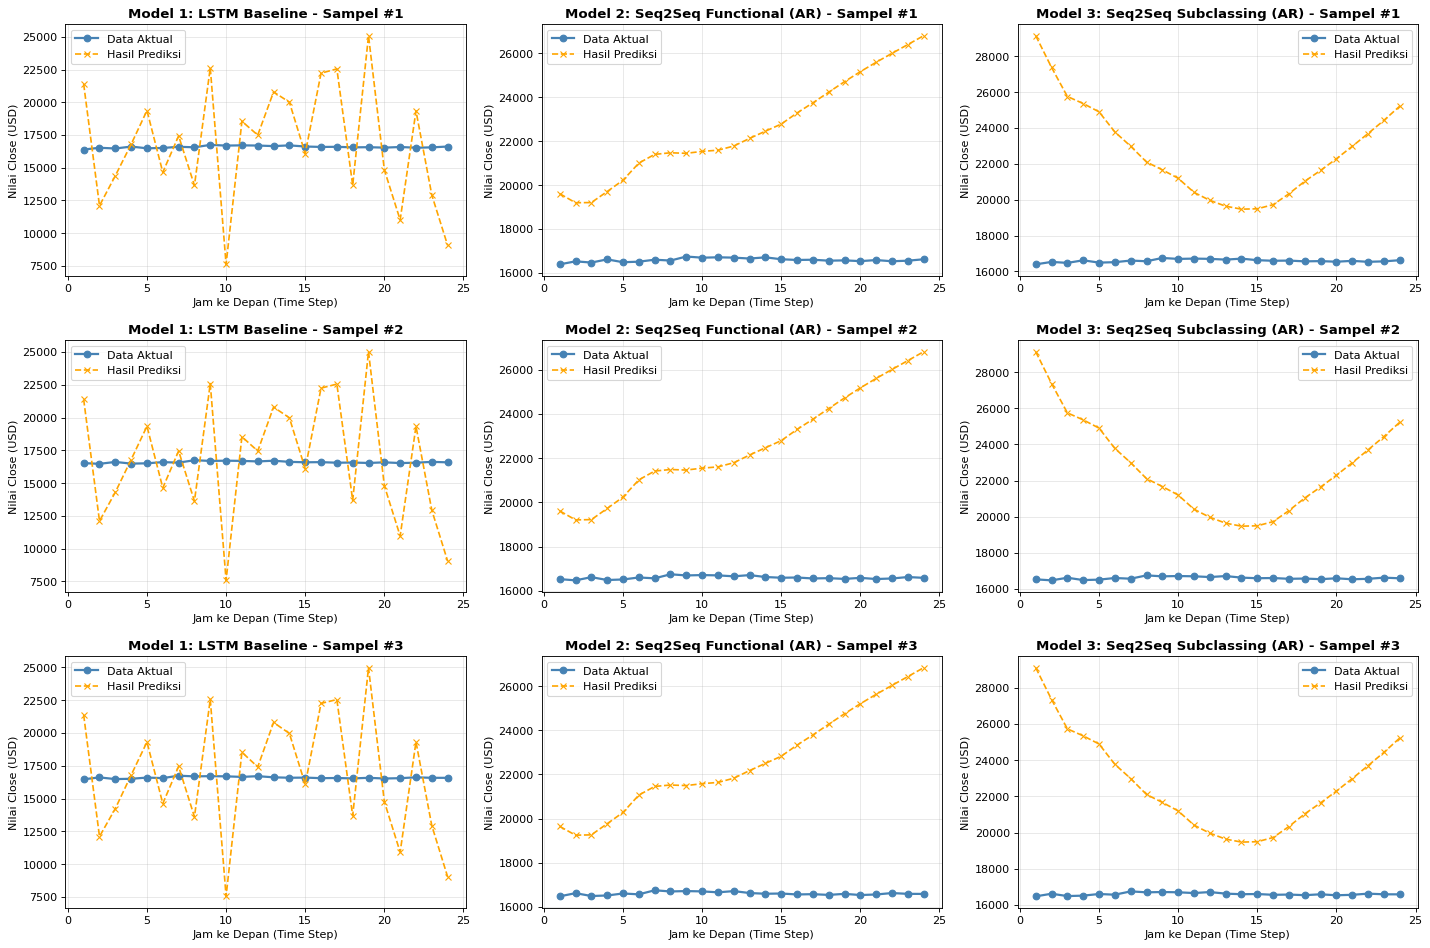

In [ ]:
def inverse_transform_seq(y_seq, scaler):
    return scaler.inverse_transform(y_seq.reshape(-1, 1)).flatten()

NUM_SAMPLES = 3
fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(18, 4*NUM_SAMPLES))
for i in range(NUM_SAMPLES):
    actual = inverse_transform_seq(y_test_ar[i], target_scaler)
    pred_m1 = inverse_transform_seq(preds_m1[i], target_scaler)
    pred_m2 = inverse_transform_seq(preds_m2_ar[i], target_scaler)
    pred_m3 = inverse_transform_seq(preds_m3_ar[i], target_scaler)

    for j, (pred, name) in enumerate([
        (pred_m1, 'Model 1: LSTM Baseline'),
        (pred_m2, 'Model 2: Seq2Seq Functional (AR)'),
        (pred_m3, 'Model 3: Seq2Seq Subclassing (AR)'),
    ]):
        ax = axes[i, j]
        ax.plot(range(1, 25), actual, marker='o', linewidth=2, label='Data Aktual', color='steelblue')
        ax.plot(range(1, 25), pred, marker='x', linestyle='--', linewidth=1.5, label='Hasil Prediksi', color='orange')
        ax.set_title(f'{name} - Sampel #{i+1}', fontweight='bold')
        ax.set_xlabel('Jam ke Depan (Time Step)')
        ax.set_ylabel('Nilai Close (USD)')
        ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 28. Tabel Perbandingan Aktual vs Prediksi
Untuk Model 3 (Seq2Seq Subclassing) dengan Autoregressive inference.

In [ ]:
actual_inv = inverse_transform_seq(y_test_ar[0], target_scaler)
pred_inv = inverse_transform_seq(preds_m3_ar[0], target_scaler)

df_compare = pd.DataFrame({
    'Jam ke': range(1, 25),
    'Data Aktual': actual_inv.round(2),
    'Hasil Prediksi': pred_inv.round(6),
    'Selisih': (actual_inv - pred_inv).round(6),
})
print("Tabel Perbandingan untuk Sampel #1 (24 jam ke depan):")
print(df_compare.to_string(index=False))

Tabel Perbandingan untuk Sampel #1 (24 jam ke depan):
 Jam ke  Data Aktual  Hasil Prediksi       Selisih
      1     16391.62    29155.892578 -12764.273438
      2     16527.81    27382.648438 -10854.837891
      3     16473.32    25761.470703  -9288.150391
      4     16617.47    25368.673828  -8751.203125
      5     16488.41    24904.998047  -8416.587891
      6     16512.51    23781.181641  -7268.671875
      7     16603.11    22985.144531  -6382.035156
      8     16564.07    22103.451172  -5539.380859
      9     16747.83    21665.927734  -4918.097168
     10     16695.18    21197.134766  -4501.953125
     11     16823.43    20741.378906  -3917.948242
     12     16847.94    20308.486328  -3460.546875
     13     16871.09    19890.876953  -3019.787109
     14     16834.51    19497.458984  -2662.949219
     15     16805.20    19129.812500  -2324.612305
     16     16804.97    18785.664062  -1980.694336
     17     16807.30    18470.041016  -1662.741211
     18     16850.50    1818